## **Modelos com Implementação Própria, NumPy**

**Tarefa 2 do Trabalho Prático — Aprendizagem Profunda**

Notebook que implementa e compara modelos de classificação de texto (Human vs AI) usando apenas NumPy:

1. **Baseline — Regressão Logística Multi-Classe** (Softmax Regression)
2. **DNN — Deep Neural Network** com várias arquiteturas
3. **Comparação de técnicas de regularização** (Dropout vs L2 vs ambos)
4. **Avaliação final** com métricas, curvas de aprendizagem e matrizes de confusão

### **1. Imports e Carregamento dos Dados**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time

# Adicionar o caminho para o diretório src
sys.path.append(os.path.abspath('../src'))

# Modelos from scratch
from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam, SGD
from logisticregression import LogisticRegression

# Pipeline de features (NumPy puro)
from utils import prepare_text_data, transform_new_texts

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

### **2. Preparação dos Dados**

In [2]:
print("A carregar os datasets...")

# Dataset de treino e validação
df_train_val = pd.read_csv('../data/dataset.csv', sep=';')
df_train_val.columns = df_train_val.columns.str.lower()
textos_train_val = df_train_val['text'].tolist()
labels_train_val = df_train_val['label'].tolist()

# Dataset de teste
df_test = pd.read_csv('../data/raw/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f"  Dataset de treino e validação: {len(textos_train_val)} textos")
print(f"  Dataset de teste: {len(textos_test)} textos")

print("\nA processar features (TF-IDF word + char + estilísticas)...")
X_train, Y_train, X_val, Y_val, transformers, encoder = prepare_text_data(
    textos_train_val,
    labels_train_val,
    max_features=1000,
    char_features=1000,
    val_size=0.30,
    use_stratify=True,
    ngram_range=(1, 2)
)

print("A processar features do dataset de teste...")
X_test = transform_new_texts(textos_test, transformers)
Y_test = encoder.transform(np.array(labels_test))

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
class_names = encoder.classes

print(f"\n✅ Dados prontos:")
print(f"  Treino:    {X_train.shape}")
print(f"  Validação: {X_val.shape}")
print(f"  Teste:     {X_test.shape}")
print(f"  Classes:   {list(class_names)}")

A carregar os datasets...
  Dataset de treino e validação: 2500 textos
  Dataset de teste: 125 textos

A processar features (TF-IDF word + char + estilísticas)...
A processar features do dataset de teste...

✅ Dados prontos:
  Treino:    (1750, 2013)
  Validação: (750, 2013)
  Teste:     (125, 2013)
  Classes:   [np.str_('Anthropic'), np.str_('Google'), np.str_('Human'), np.str_('Meta'), np.str_('OpenAI')]


### **3. Baseline — Regressão Logística Multi-Classe (Softmax)**

O enunciado exige um modelo baseline de regressão logística. Implementámos uma Softmax Regression
(generalização multi-classe da regressão logística binária) com:
- Categorical Cross-Entropy como função de custo
- Mini-batch gradient descent
- Regularização L2
- Early stopping

In [3]:
np.random.seed(42)

print("Baseline: Regressão Logística Multi-Classe")

lr_model = LogisticRegression(
    n_features=input_dim,
    n_classes=output_dim,
    learning_rate=0.05,
    l2_lambda=0.001
)

t0 = time.time()
lr_model.fit(
    X_train, Y_train,
    epochs=300,
    batch_size=64,
    verbose=True,
    X_val=X_val, Y_val=Y_val,
    patience=15
)
tempo_lr = time.time() - t0

# Avaliar
lr_train_loss, lr_train_acc = lr_model.evaluate(X_train, Y_train)
lr_val_loss, lr_val_acc = lr_model.evaluate(X_val, Y_val)
lr_test_loss, lr_test_acc = lr_model.evaluate(X_test, Y_test)

print(f"\nResultados da baseline:")
print(f"  Treino      — Loss: {lr_train_loss:.4f} | Accuracy: {lr_train_acc:.2%}")
print(f"  Validação   — Loss: {lr_val_loss:.4f} | Accuracy: {lr_val_acc:.2%}")
print(f"  Teste       — Loss: {lr_test_loss:.4f} | Accuracy: {lr_test_acc:.2%}")
print(f"  Tempo: {tempo_lr:.1f}s")

Baseline: Regressão Logística Multi-Classe
Epoch    1/300 | Loss: 1.3526 | Val Loss: 1.3811 | Acc: 48.06% | Val Acc: 46.93%
Epoch   11/300 | Loss: 1.1121 | Val Loss: 1.1676 | Acc: 54.97% | Val Acc: 53.07%
Epoch   21/300 | Loss: 1.0791 | Val Loss: 1.1353 | Acc: 56.40% | Val Acc: 53.60%
Epoch   31/300 | Loss: 1.0589 | Val Loss: 1.1161 | Acc: 58.06% | Val Acc: 54.13%
Epoch   41/300 | Loss: 1.0422 | Val Loss: 1.0985 | Acc: 59.09% | Val Acc: 55.47%
Epoch   51/300 | Loss: 1.0268 | Val Loss: 1.0844 | Acc: 60.00% | Val Acc: 55.60%
Epoch   61/300 | Loss: 1.0123 | Val Loss: 1.0736 | Acc: 61.37% | Val Acc: 56.67%
Epoch   71/300 | Loss: 0.9983 | Val Loss: 1.0645 | Acc: 62.00% | Val Acc: 57.07%
Epoch   81/300 | Loss: 0.9850 | Val Loss: 1.0565 | Acc: 62.97% | Val Acc: 57.33%
Epoch   91/300 | Loss: 0.9720 | Val Loss: 1.0495 | Acc: 63.71% | Val Acc: 58.53%
Epoch  101/300 | Loss: 0.9596 | Val Loss: 1.0418 | Acc: 64.23% | Val Acc: 58.40%
Epoch  111/300 | Loss: 0.9473 | Val Loss: 1.0342 | Acc: 65.09% | V

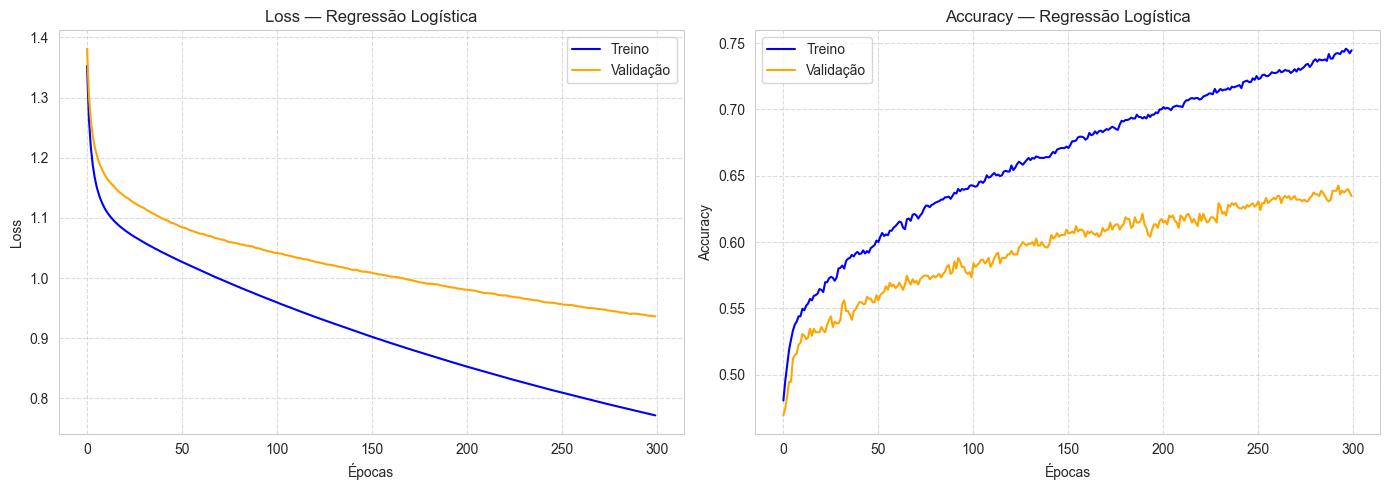

In [4]:
# Curvas de aprendizagem do Baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_model.history['loss'], label='Treino', color='blue')
axes[0].plot(lr_model.history['val_loss'], label='Validação', color='orange')
axes[0].set_title('Loss — Regressão Logística')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(lr_model.history['acc'], label='Treino', color='blue')
axes[1].plot(lr_model.history['val_acc'], label='Validação', color='orange')
axes[1].set_title('Accuracy — Regressão Logística')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **4. Deep Neural Networks — Exploração de Arquiteturas**

Vamos testar várias configurações de DNN para encontrar a melhor:
- **DNN A** — Rede larga: 512 → 128 → 5 (Dropout 0.4)
- **DNN B** — Rede estreita e profunda: 256 → 128 → 64 → 5 (Dropout 0.3)

Todas usam ReLU + Softmax + Adam + Early Stopping.

In [5]:
def treinar_dnn(nome, camadas_config, epochs=300, batch_size=32, patience=15):
    """
    Constrói e treina uma DNN a partir de uma lista de configurações de camadas.
    
    camadas_config: lista de tuplos (n_units, dropout_rate, l2_lambda)
        Ex: [(256, 0.3, 0.0), (64, 0.3, 0.0)] = 2 hidden layers
    """
    np.random.seed(42)
    adam = Adam(learning_rate=0.0005)
    nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())
    
    prev_units = input_dim
    for n_units, dropout, l2 in camadas_config:
        nn.add(DenseLayer(input_shape=prev_units, n_units=n_units, optimizer=adam, l2_lambda=l2))
        nn.add(ReLUActivation())
        if dropout > 0:
            nn.add(DropoutLayer(rate=dropout))
        prev_units = n_units
    
    # Camada de saída
    nn.add(DenseLayer(input_shape=prev_units, n_units=output_dim, optimizer=adam))
    nn.add(SoftmaxActivation())
    
    desc = " → ".join([str(c[0]) for c in camadas_config]) + f" → {output_dim}"
    print(f"{nome}: {desc}")
    
    t0 = time.time()
    nn.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,
           verbose=True, X_val=X_val, Y_val=Y_val, patience=patience)
    tempo = time.time() - t0
    
    train_loss, train_acc = nn.evaluate(X_train, Y_train)
    val_loss, val_acc = nn.evaluate(X_val, Y_val)
    test_loss, test_acc = nn.evaluate(X_test, Y_test)
    
    print(f"\n  Treino    — Acc: {train_acc:.2%}")
    print(f"  Validação — Acc: {val_acc:.2%}")
    print(f"  Teste     — Acc: {test_acc:.2%}")
    print(f"  Tempo: {tempo:.1f}s")
    
    return nn, {
        'nome': nome,
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'train_loss': train_loss, 'val_loss': val_loss, 'test_loss': test_loss,
        'tempo': tempo, 'history': nn.history
    }

In [6]:
# Treinar as 3 arquiteturas
resultados = {}

# DNN A — Larga
nn_a, res_a = treinar_dnn("DNN A (512→128)", [
    (512, 0.4, 0.0),
    (128, 0.4, 0.0),
])
resultados['DNN A'] = res_a

# DNN B — Profunda
nn_b, res_b = treinar_dnn("DNN B (256→128→64)", [
    (256, 0.3, 0.0),
    (128, 0.3, 0.0),
    (64,  0.3, 0.0),
])
resultados['DNN B'] = res_b
# DNN C — Regularizada
nn_c, res_c = treinar_dnn("DNN C (256→128→64)", [
    (256, 0.4, 0.001),
    (128, 0.4, 0.001),
    (64,  0.4, 0.001),
])
resultados['DNN C'] = res_c

DNN A (512→128): 512 → 128 → 5
Epoch 1/300 | Loss: 1.1371 | Val Loss: 1.2075 | Train Acc: 56.91% | Val Acc: 50.80%
Epoch 11/300 | Loss: 0.0592 | Val Loss: 0.7000 | Train Acc: 99.54% | Val Acc: 75.07%
Epoch 21/300 | Loss: 0.0058 | Val Loss: 0.8791 | Train Acc: 99.94% | Val Acc: 74.67%

Early Stopping na epoca 22! Val Loss nao melhorou ha 15 epocas.
Melhor Val Loss: 0.6972
Melhores pesos restaurados.

  Treino    — Acc: 95.71%
  Validação — Acc: 73.87%
  Teste     — Acc: 52.00%
  Tempo: 63.5s
DNN B (256→128→64): 256 → 128 → 64 → 5
Epoch 1/300 | Loss: 1.2605 | Val Loss: 1.3029 | Train Acc: 51.03% | Val Acc: 47.20%
Epoch 11/300 | Loss: 0.0506 | Val Loss: 0.7761 | Train Acc: 99.31% | Val Acc: 74.53%
Epoch 21/300 | Loss: 0.0031 | Val Loss: 1.0620 | Train Acc: 100.00% | Val Acc: 71.60%

Early Stopping na epoca 23! Val Loss nao melhorou ha 15 epocas.
Melhor Val Loss: 0.7135
Melhores pesos restaurados.

  Treino    — Acc: 95.77%
  Validação — Acc: 73.60%
  Teste     — Acc: 48.00%
  Tempo: 33.0s

### **5. Comparação de Regularização**

Usando a melhor arquitetura, comparamos:
- **Dropout only** (já testado acima)
- **L2 only** (weight decay, sem Dropout)
- **Dropout + L2** (combinação de ambos)

In [7]:
# L2 only (sem Dropout)
nn_l2, res_l2 = treinar_dnn("DNN + L2", [
    (256, 0.0, 0.001),
    (32,  0.0, 0.001),
])
resultados['DNN L2'] = res_l2

# Dropout + L2
nn_both, res_both = treinar_dnn("DNN + Dropout + L2", [
    (256, 0.3, 0.001),
    (32,  0.3, 0.001),
])
resultados['DNN D+L2'] = res_both

DNN + L2: 256 → 32 → 5
Epoch 1/300 | Loss: 1.1643 | Val Loss: 1.2315 | Train Acc: 58.63% | Val Acc: 53.07%
Epoch 11/300 | Loss: 0.1026 | Val Loss: 0.6792 | Train Acc: 99.60% | Val Acc: 74.93%
Epoch 21/300 | Loss: 0.0398 | Val Loss: 0.7373 | Train Acc: 99.94% | Val Acc: 74.67%

Early Stopping na epoca 23! Val Loss nao melhorou ha 15 epocas.
Melhor Val Loss: 0.6762
Melhores pesos restaurados.

  Treino    — Acc: 98.29%
  Validação — Acc: 75.33%
  Teste     — Acc: 48.00%
  Tempo: 34.3s
DNN + Dropout + L2: 256 → 32 → 5
Epoch 1/300 | Loss: 1.2869 | Val Loss: 1.3320 | Train Acc: 54.34% | Val Acc: 49.07%
Epoch 11/300 | Loss: 0.2368 | Val Loss: 0.6757 | Train Acc: 96.57% | Val Acc: 74.67%
Epoch 21/300 | Loss: 0.0654 | Val Loss: 0.6886 | Train Acc: 99.83% | Val Acc: 73.60%
Epoch 31/300 | Loss: 0.0281 | Val Loss: 0.7302 | Train Acc: 99.94% | Val Acc: 74.13%

Early Stopping na epoca 31! Val Loss nao melhorou ha 15 epocas.
Melhor Val Loss: 0.6650
Melhores pesos restaurados.

  Treino    — Acc: 98.

### **6. Curvas de Aprendizagem**

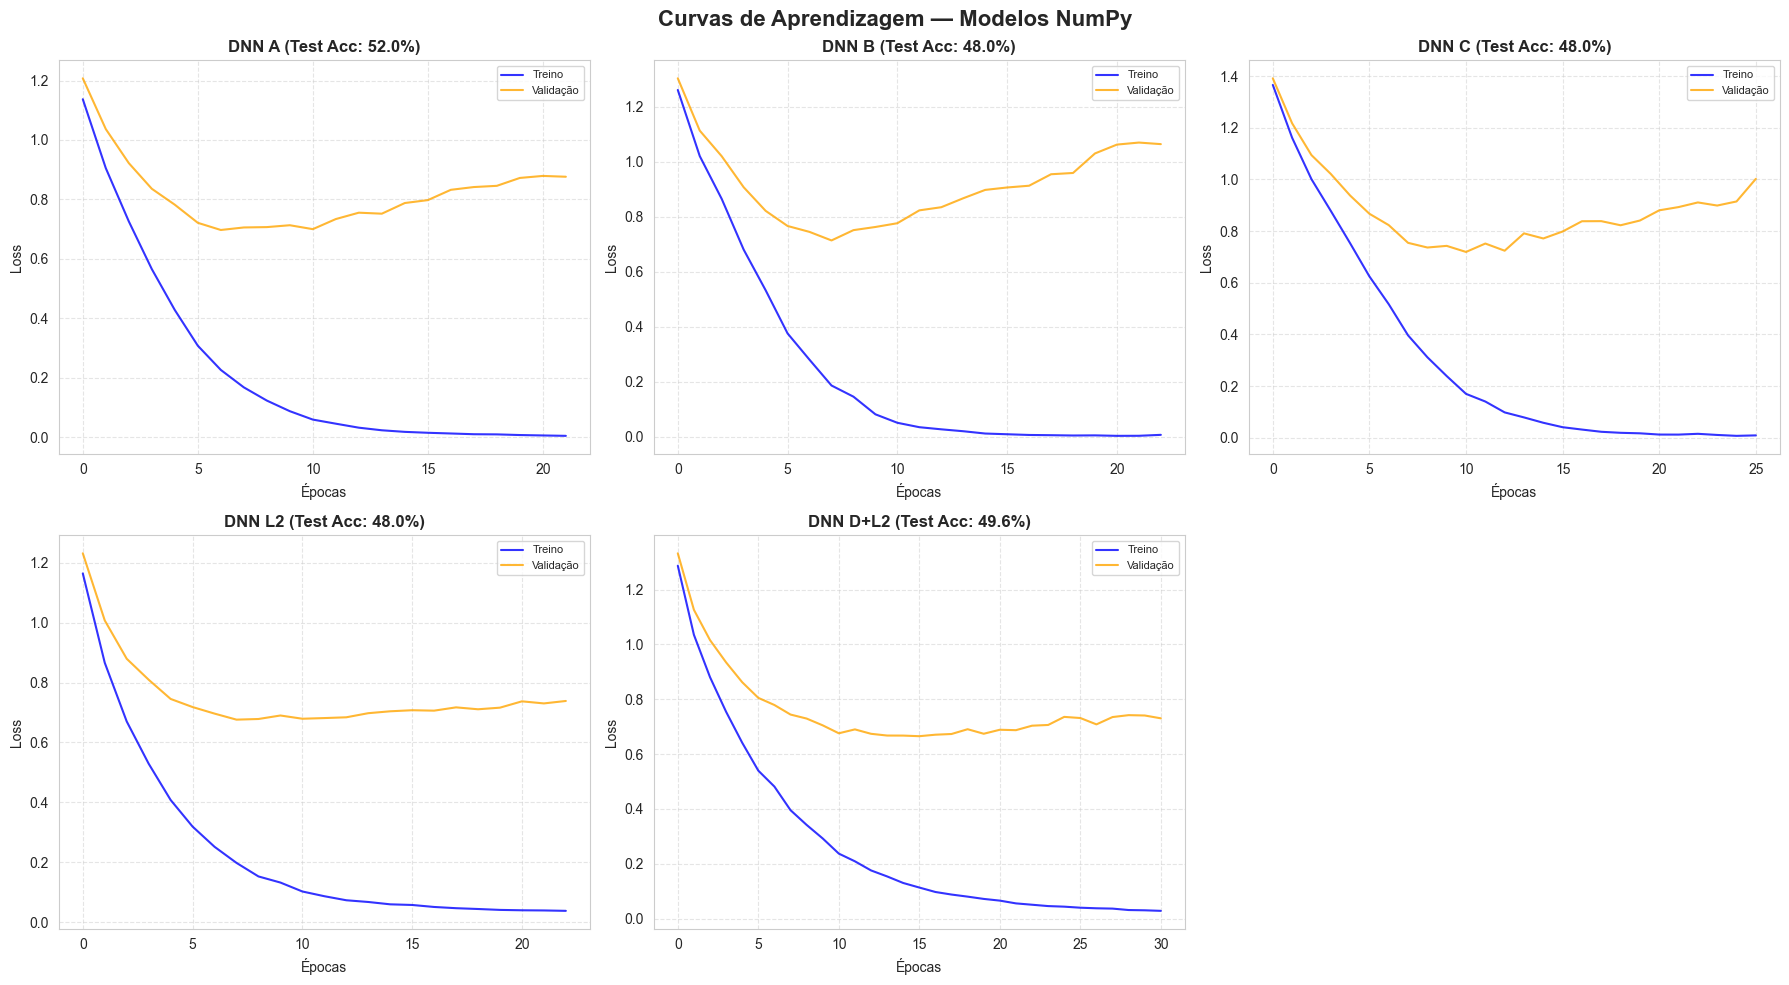

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

modelos_plot = [
    ('DNN A', res_a), ('DNN B', res_b), ('DNN C', res_c),
    ('DNN L2', res_l2), ('DNN D+L2', res_both),
]

for idx, (nome, res) in enumerate(modelos_plot):
    ax = axes[idx // 3][idx % 3]
    ax.plot(res['history']['loss'], label='Treino', color='blue', alpha=0.8)
    ax.plot(res['history']['val_loss'], label='Validação', color='orange', alpha=0.8)
    ax.set_title(f"{nome} (Test Acc: {res['test_acc']:.1%})", fontweight='bold')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagar o subplot vazio
axes[1][2].axis('off')

plt.suptitle('Curvas de Aprendizagem — Modelos NumPy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **7. Comparação de Todos os Modelos**

In [9]:
# Adicionar o baseline à comparação
resultados['Baseline LR'] = {
    'nome': 'Baseline LR',
    'train_acc': lr_train_acc, 'val_acc': lr_val_acc, 'test_acc': lr_test_acc,
    'train_loss': lr_train_loss, 'val_loss': lr_val_loss, 'test_loss': lr_test_loss,
    'tempo': tempo_lr
}

# Construir tabela
rows = []
for key, res in resultados.items():
    rows.append({
        'Modelo': res['nome'],
        'Train Acc': f"{res['train_acc']:.2%}",
        'Val Acc': f"{res['val_acc']:.2%}",
        'Test Acc': f"{res['test_acc']:.2%}",
        'Test Loss': f"{res['test_loss']:.4f}",
        'Tempo (s)': f"{res['tempo']:.1f}",
    })

df_resultados = pd.DataFrame(rows)
df_resultados = df_resultados.sort_values('Test Acc', ascending=False)
print(df_resultados.to_string(index=False))

            Modelo Train Acc Val Acc Test Acc Test Loss Tempo (s)
   DNN A (512→128)    95.71%  73.87%   52.00%    1.8234      63.5
       Baseline LR    74.46%  63.47%   50.40%    1.4034       6.4
DNN + Dropout + L2    98.97%  75.47%   49.60%    1.8407      46.1
DNN B (256→128→64)    95.77%  73.60%   48.00%    2.0712      33.0
DNN C (256→128→64)    96.69%  72.53%   48.00%    2.3608      41.2
          DNN + L2    98.29%  75.33%   48.00%    1.6599      34.3


### **8. Avaliação do Melhor Modelo**

In [10]:
# Selecionar o melhor modelo pelo test_acc
melhor_key = max(resultados, key=lambda k: resultados[k]['test_acc'])
print(f"🏆 Melhor modelo: {resultados[melhor_key]['nome']}")

# Encontrar o objeto do modelo correspondente
modelos_obj = {
    'DNN A': nn_a, 'DNN B': nn_b, 'DNN C': nn_c,
    'DNN L2': nn_l2, 'DNN D+L2': nn_both
}

if melhor_key == 'Baseline LR':
    y_pred_test = lr_model.predict(X_test)
    y_true_test = np.argmax(Y_test, axis=1)
else:
    melhor_nn = modelos_obj[melhor_key]
    y_pred_proba = melhor_nn.predict(X_test)
    y_pred_test = np.argmax(y_pred_proba, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

🏆 Melhor modelo: DNN A (512→128)


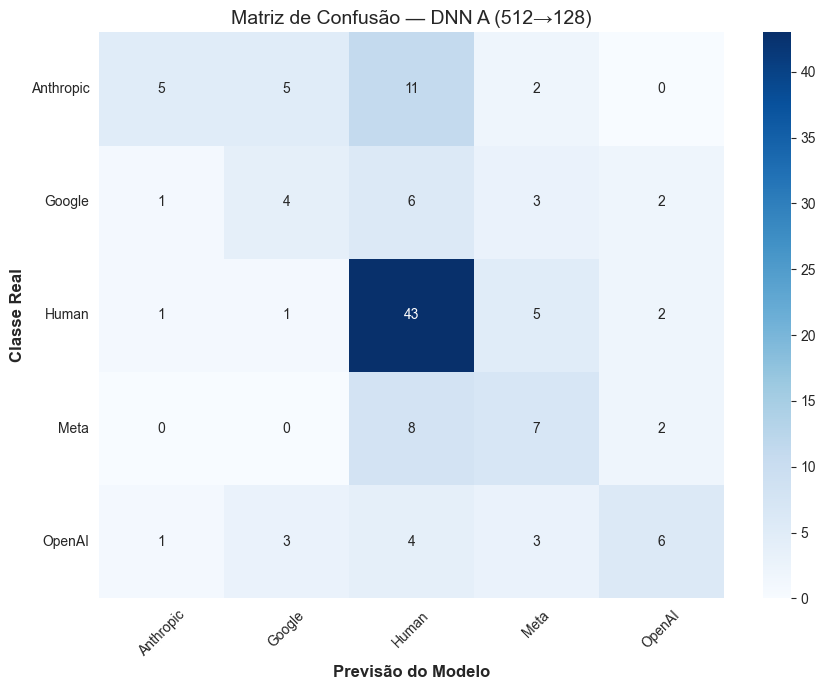


Classification Report — DNN A (512→128):
              precision    recall  f1-score   support

   Anthropic       0.62      0.22      0.32        23
      Google       0.31      0.25      0.28        16
       Human       0.60      0.83      0.69        52
        Meta       0.35      0.41      0.38        17
      OpenAI       0.50      0.35      0.41        17

    accuracy                           0.52       125
   macro avg       0.48      0.41      0.42       125
weighted avg       0.52      0.52      0.49       125



In [11]:
# Matriz de Confusão
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {resultados[melhor_key]["nome"]}', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report — {resultados[melhor_key]['nome']}:")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))

### **9. Guardar o Modelo**

In [12]:
import pickle

# Guardar o melhor modelo + transformadores para submissão
modelo_para_guardar = {
    'modelo_tipo': melhor_key,
    'transformers': transformers,
    'encoder': encoder,
    'class_names': class_names,
}

if melhor_key == 'Baseline LR':
    modelo_para_guardar['weights'] = lr_model.weights
    modelo_para_guardar['biases'] = lr_model.biases
else:
    melhor_nn = modelos_obj[melhor_key]
    pesos = []
    for layer in melhor_nn.layers:
        if hasattr(layer, 'get_weights'):
            pesos.append(layer.get_weights())
        else:
            pesos.append(None)
    modelo_para_guardar['pesos_camadas'] = pesos

caminho = '../models/numpy.pkl'
os.makedirs('../models', exist_ok=True)
with open(caminho, 'wb') as f:
    pickle.dump(modelo_para_guardar, f)
    
print(f"✅ Modelo guardado em '{caminho}'")

✅ Modelo guardado em '../models/numpy.pkl'
